### Tutorial 1: Training a Drug-Target Interaction (DTI) Model from Scratch
#### Sourced from [@KexinHuang5](https://twitter.com/KexinHuang5)
- Tutorial 1 – DTI prediction sourced from the DeepPurpose GitHub repository and associated documentation [**Original GitHub Repo**](https://github.com/kexinhuang12345/DeepPurpose/blob/master/Tutorial_1_DTI_Prediction.ipynb)


**DeepPurpose package:** PyTorch‑based deep‑learning toolkit for DTI, drug‑property, and related tasks.
In Tutorial 1: we take a deep dive into DeepPurpose and show how it builds a drug-target interaction model from scratch. 

Tutorial_1_DTI_Prediction:
- Part I: Overview of DeepPurpose and Data
- Part II: Drug Target Interaction Prediction
    - DeepPurpose Framework
    - Applications to Drug Repurposing and Virtual Screening
    - Pretrained Models
    - Hyperparameter Tuning
    - Model Robustness Evaluation

Let's start!
Run the following commands on a separate command prompt from notebook. Create and activate virtual environment DeepPurpose (**please call it something else** as to not confuse it with filesystem directory "DeepPurpose" where git files exist). 

- conda remove --name DeepPurpose --all     # in the case you already have a virtual environment called DeepPurpose
- conda create -n DeepPurpose python=3.10 -y
- conda activate DeepPurpose

### Run tutorial notebook in the DeepPurpose directory created by git clone command
- git clone https://github.com/kexinhuang12345/DeepPurpose.git
- cd C:\... \path to your HW09\ ...\DeepPurpose

**Activate virtual conda environment (above)**
- **Determine the version of Cuda by invoking `nvcc` --version'**
- **Change the number in the string cu130, accordingly**
- pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

**If you want to be able to select environment dependent kernel in the notebook, do the following:**
- **please call conda env something else than "DeepPurpose" per virtual env, kernel display, etc.**
- python -m ipykernel install --user --name DeepPurpose --display-name "DeepPurpose"

**Install RDkit separately from conda-forge in the activated environment:**
- conda install -c conda-forge rdkit

**Install all the packages listed below, including `DeepPurpose` package**
- **pip install DeepPurpose** 
- pip install matplotlib
- pip install pandas  
- pip install gradio==3.28.1

**Run the following installations**
- pip install git+https://github.com/bp-kelley/descriptastorus 
- pip install pandas-flavor
- pip install subword_nmt
- pip install scikit-learn
- pip install lifelines
- pip install prettytable
- pip install tensorboard

In [1]:
#  1. SILENCE EVERYTHING FIRST (BEFORE ANY IMPORTS!)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'    # 0=all, 1=filter INFO, 2=filter WARNINGS, 3=ERROR ONLY
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN
os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'   # RDKit silence
from pathlib import Path
# 2. NOW import everything
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Kill RDKit

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")
# Suppress only this torch.load / weights_only warning
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

from DeepPurpose import utils, dataset, DTI as models
from DeepPurpose import utils, dataset, CompoundPred  # This DeepPurpose is the local directory
import tensorflow as tf

# Cell 1: Auto-setup toy_data
# In Jupyter - # Test load, finds files automatically

# Clone if needed
if not os.path.exists('DeepPurpose'):
    !git clone https://github.com/kexinhuang12345/DeepPurpose.git

# Create DeepPurpose (BROAD INST structure
Path('./DeepPurpose/toy_data').mkdir(parents=True, exist_ok=True)

# Copy toy_data files
toy_files = Path('./DeepPurpose/toy_data').glob('*.txt')
for f in toy_files:
    dest = Path('./DeepPurpose/toy_data') / f.name
    dest.write_bytes(f.read_bytes())
    print(f"Copied {f.name}")

# DATA CHECK - Works regardless of folder structure #### try AID1706.txt or ddi.txt
X_drugs, X_targets, y = dataset.read_file_training_dataset_bioassay('./DeepPurpose/toy_data/AID1706.txt')
print(f"\n SUCCESS: {len(X_drugs)} drug-target pairs loaded!")
print("Loaded AID1706 toy data:")
print(f"Drugs: {len(X_drugs)}, Targets: {len(X_targets)}, Labels: {len(y)}")
print("Sample drug:", X_drugs[0][:50] + "...")
print('Drug 1: ' + X_drugs[0])
print('Score 1: ' + str(y[0]))

X_drugs, y, drugs_index = dataset.load_HIV(path = './data')
print('Test Data - HIV Drug 1: ' + X_drugs[0])
print('Test Data - HIV Score 1: ' + str(y[0]))

print('DeepPurpose OK')
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())



Download zip file...


Copied RNA_polymerase_SARS_CoV2_target_seq.txt
Copied AID1706.txt
Copied ddi.txt
Copied ames_data.txt
Copied dti.txt
Copied ppi.txt
Copied repurposing_data_examples.txt

 SUCCESS: 24 drug-target pairs loaded!
Loaded AID1706 toy data:
Drugs: 24, Targets: 307, Labels: 24
Sample drug: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3...
Drug 1: CCOC1=CC=C(C=C1)N2C=CC(=O)C(=N2)C(=O)NC3=CC=C(C=C3)S(=O)(=O)NC4=NC=CC=N4
Score 1: 0.0
 40% [..............................                                              ] 172032 / 426931

Extract zip file...


100% [............................................................................] 426931 / 426931Test Data - HIV Drug 1: CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2
Test Data - HIV Score 1: 0
DeepPurpose OK
2.11.0+cu128
12.8
True


## Part I: Overview of DeepPurpose and Data

Drug-target interaction measures the binding of drug molecules to the protein targets. Accurate identification of DTI is fundamental for drug discovery and supports many downstream tasks. Among others, drug screening and repurposing are two main applications based on DTI. Drug screening helps identify ligand candidates that can bind to the protein of interest, whereas drug repurposing finds new therapeutic purposes for existing drugs. Both tasks could alleviate the costly, time-consuming, and labor-intensive process of synthesis and analysis, which is extremely important, especially in the cases of hunting effective and safe treatments for COVID-19.

DeepPurpose is a pytorch-based deep learning framework that is initiated to provide a simple but powerful toolkit for drug-target interaction prediction and its related applications. We see many exciting recent works in this direction, but to leverage these models, it takes lots of efforts due to the esoteric instructions and interface. DeepPurpose is designed to make things as simple as possible using a unified framework.

DeepPurpose uses an encoder-decoder framework. Drug repurposing and screening are two applications after we obtain DTI models. The input to the model is a drug target pair, where drug uses the simplified molecular-input line-entry system (SMILES) string and target uses the amino acid sequence. The output is a score indicating the binding activity of the drug target pair. Now, we begin talking about the data format expected.


(**Data**) DeepPurpose takes into an array of drug's SMILES strings (**d**), an array of target protein's amino acid sequence (**t**), and an array of label (**y**), which can either be binary 0/1 indicating interaction outcome or a real number indicating affinity value. The input drug and target arrays should be paired, i.e. **y**\[0\] is the score for **d**\[0\] and **t**\[0\].

Besides transforming into numpy arrays through some data wrangling on your own, DeepPurpose also provides two ways to help data preparation. 

The first way is to read from local files. For example, to load drug target pairs, we expect a file.txt where each line is a drug SMILES string, followed by a protein sequence, and an affinity score or 0/1 label:

```CC1=C...C4)N MKK...LIDL 7.365``` \
```CC1=C...C4)N QQP...EGKH 4.999```

Then, we use ```dataset.read_file_training_dataset_drug_target_pairs``` to load it.


**Drug1:** The string is a SMILES representation of a chemical structure, not a drug name. It looks like a heteroaromatic, amine-containing small molecule, which is consistent with many medicinal chemistry compounds

**Target1:** sequence appears to be a kinase family target ... domain from a serine/threonine protein kinase, and the best match is a cyclin-dependent kinase–type target, most likely CDK9 or a very close CDK-family homolog. This exact sequence style is often seen in target databases for transcription-associated kinases

Make sure that your `read_file_...(..../dti.txt) point to an existing file

In [24]:
X_drugs, X_targets, y = dataset.read_file_training_dataset_drug_target_pairs('./DeepPurpose/toy_data/dti.txt')
print('Drug 1: ' + X_drugs[0])
print('Target 1: ' + X_targets[0])
print('Score 1: ' + str(y[0]))

Drug 1: CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N
Target 1: MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELLNKDFAKLGEGKHPEKLGGSAESLIPGFQSTQGDAFATTSFSAGTAEKRKGGQTVDSGLPLLSVSDPFIPLQVPDAPEKLIEGLKSPDTSLLLPDLLPMTDPFGSTSDAVIEKADVAVESLIPGLEPPVPQRLPSQTESVTSNRTDSLTGEDSLLDCSLLSNPTTDLLEEFAPTAISAPVHKAAEDSNLISGFDVPEGSDKVAEDEFDPIPVLITKNPQ

Many method researchers want to test on benchmark datasets such as KIBA/DAVIS/BindingDB, DeepPurpose also provides data loaders to ease preprocessing. For example, we want to load the DAVIS dataset, we can use ```dataset.load_process_DAVIS```. It will download, preprocess to the designated data format. It supports label log-scale transformation for easier regression and also allows label binarization given a customized threshold.

In [25]:
X_drugs, X_targets, y = dataset.load_process_DAVIS(path = './lab09_data', binary = False, convert_to_log = True, threshold = 30)
print('Drug 1: ' + X_drugs[0])
print('Target 1: ' + X_targets[0])
print('Score 1: ' + str(y[0]))

Beginning Processing...
100% [............................................................................] 179878 / 179878Beginning to extract zip file...
Default set to logspace (nM -> p) for easier regression
Done!
Drug 1: CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N
Target 1: MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELL

For more detailed examples and tutorials of data loading, checkout this [tutorial](./DEMO/load_data_tutorial.ipynb).

## Part II: Drug Target Interaction Prediction Framework

DeepPurpose provides a simple framework to conduct DTI research using 8 encoders for drugs and 7 for proteins. It basically consists of the following steps, where each step corresponds to one line of code:

- Encoder specification
- Data encoding and split
- Model configuration generation
- Model initialization
- Model Training
- Model Prediction and Repuposing/Screening
- Model Saving and Loading

Let's start with data encoding! 

(**Encoder specification**) After we obtain the required data format from Part I, we need to prepare them for the encoders. Hence, we first specify the encoder to use for drug and protein. Here we try MPNN for drug and CNN for target.

If you find MPNN and CNN are too large for the CPUs, you can try smaller encoders by uncommenting the last line:
**Morgan handles small-molecule drugs effectively, while Conjoint_triad suits protein targets by focusing on amino acid triad properties.**

In [26]:
drug_encoding, target_encoding = 'MPNN', 'CNN'
#drug_encoding, target_encoding = 'Morgan', 'Conjoint_triad'

Note that you can switch encoder just by changing the encoding name above. The full list of encoders are listed [here](https://github.com/kexinhuang12345/DeepPurpose#encodings). Here, we are using the message passing neural network encoder for drug and convolutional neural network encoder for protein.

### **Use the right Encoder, with right data (drug or target), with right pre-trained model!**
- **MPNN is a DRUG encoder only - cannot use for Target_encoding (proteins). Use CNN/Transformer for proteins.**
- <font color="#DC143C">**Compound (drug only) prediction**</font> → **1 encoder, only drug** (Morgan or MPNN)
- <font color="#DC143C">**DTI / repurposing**</font> → **2 encoders, drug + protein** (Morgan or MPNN for drug, CNN or MPNN for target)
- `Morgan` is a **2D‑fingerprint** encoder for Drugs (Needs valid SMILES) e.g., circular “ECFP‑style” Morgan fingerprints) f, and is one of the standard `drug_encoding` options in DeepPurpose alongside `MPNN`, `CNN`, `Daylight`, and `Pubchem`.  
- `AAC` and `PAAC` are **physicochemical / compositional** protein‑sequence encodings, while `CNN_RNN` and `Transformer` are **deep‑learning** protein encoders.

### **Use the right data format too!**
- **<font color="#DC143C">DeepPurpose</font> uses RDKit <font color="#DC143C">Morgan</font>/ECFP fingerprints which <font color="#DC143C">Always use Isomeric SMILES</font>(@, @@, /, \) for meaningful results**
- See files in  DeepPurpose folder to easily reformat Mol to SMILE ... /DTI/data_processing.py

| **drug_encoding**     | Encoder type (drug)                  | Good for which task?                                                    | **target_encoding** | Encoder type (protein)                  |
| ----------------------- | ------------------------------------ | ----------------------------------------------------------------------- | --------------------- | --------------------------------------- |
| 'Morgan'                | 2D fingerprint (ECFP‑style)          | Ames‑style tox, solubility, general DTI.                                | 'CNN'                 | 1D CNN on amino‑acid sequence.          |
| 'MPNN'                  | Message‑Passing Graph Neural Network | Rich‑structure mutagenicity, DTI, PPI/AA‑aware features.                | 'CNN_RNN'             | CNN + RNN on sequence.                  |
| 'CNN'                   | CNN on SMILES tokens                 | General DTI / compound‑property if you want deep SMILES‑level modeling. | 'Transformer'         | Protein‑sequence Transformer.           |
| 'RNN'                   | RNN on top of SMILES‑CNN             | More sequence‑like modeling of SMILES.                                  | 'AAC'                 | Amino Acid Composition (MLP on counts). |
| 'Daylight'              | Daylight‑type fingerprints           | Ames‑style tox, basic DTI baseline.                                     | 'PseudoAAC'           | Pseudo‑Amino‑Acid‑Composition features. |
| 'Pubchem'               | PubChem‑881‑bit fingerprint          | Simple DTI / chem‑informatics baselines.                                | 'Conjoint_triad'      | Conjunct triad‑style sequence features. |
| 'Transformer' / sub‑IDs | Transformer‑based embeddings         | State‑of‑the‑art DTI when paired with protein‑Transformer.              | 'DDE' / others        | Distance‑distribution‑based encodings.  |


(**Data encoding and split**) Now, we encode the data into the specified format, using ```utils.data_process``` function. It specifies train/validation/test split fractions, and random seed to ensure same data splits for reproducibility. This function also support data splitting methods such as ```cold_drug``` and ```cold_protein```, which splits on drug/proteins for model robustness evaluation to test on unseen drug/proteins.

The function outputs train, val, test pandas dataframes.

In [27]:
train, val, test = utils.data_process(X_drugs, X_targets, y, 
                                drug_encoding, target_encoding, 
                                split_method='random',frac=[0.7,0.1,0.2],
                                random_seed = 1)
train.head(1)

Drug Target Interaction Prediction Mode...
in total: 30056 drug-target pairs
encoding drug...
unique drugs: 68
encoding protein...
unique target sequence: 379
splitting dataset...
Done.


,SMILES,Target Sequence,Label,drug_encoding,target_encoding
0,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,5.0,"[[[tensor(1.), tensor(0.), tensor(0.), tensor(...","[P, F, W, K, I, L, N, P, L, L, E, R, G, T, Y, ..."


(**Model configuration generation**) Now, we initialize a model with its configuration. You can modify almost any hyper-parameters (e.g., learning rate, epoch, batch size), model parameters (e.g. hidden dimensions, filter size) and etc in this function. The supported configurations are listed here in this [link](https://github.com/kexinhuang12345/DeepPurpose/blob/e169e2f550694145077bb2af95a4031abe400a77/DeepPurpose/utils.py#L486).

For the sake of example, we specify the epoch size to be 5, and set the model parameters to be small so that you can run on both CPUs & GPUs quickly and can proceed to the next steps. For a reference parameters, checkout the notebooks in the DEMO folder.

In [28]:
config = utils.generate_config(drug_encoding = drug_encoding, 
                         target_encoding = target_encoding, 
                         cls_hidden_dims = [1024,1024,512], 
                         train_epoch = 5, 
                         LR = 0.001, 
                         batch_size = 128,
                         hidden_dim_drug = 128,
                         mpnn_hidden_size = 128,
                         mpnn_depth = 3, 
                         cnn_target_filters = [32,64,96],
                         cnn_target_kernels = [4,8,12]
                        )

(**Model initialization**) Next, we initialize a model using the above configuration.

In [29]:
model = models.model_initialize(**config)
model

(**Model Training**) Next, it is ready to train, using the ```model.train``` function! If you do not have test set, you can just use ```model.train(train, val)```. 

Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 30.1393. Total time 0.0 hours
Training at Epoch 1 iteration 100 with loss 0.44337. Total time 0.00861 hours
Validation at Epoch 1 with loss:0.92933, MSE: 0.76828 , Pearson Correlation: 0.25094 with p-value: 2.16E-44 , Concordance Index: 0.63044
Training at Epoch 2 iteration 0 with loss 0.61404. Total time 0.01611 hours
Training at Epoch 2 iteration 100 with loss 0.85863. Total time 0.02472 hours
Validation at Epoch 2 with loss:0.49583, MSE: 0.72006 , Pearson Correlation: 0.35007 with p-value: 2.16E-87 , Concordance Index: 0.68025
Training at Epoch 3 iteration 0 with loss 0.80196. Total time 0.03194 hours
Training at Epoch 3 iteration 100 with loss 0.78221. Total time 0.04027 hours
Validation at Epoch 3 with loss:0.52176, MSE: 0.70631 , Pearson Correlation: 0.36804 with p-value: 4.48E-97 , Concordance Index: 0.69777
Training at Epoch 4 iteration 0 with loss 0.71440. Total time 0.0

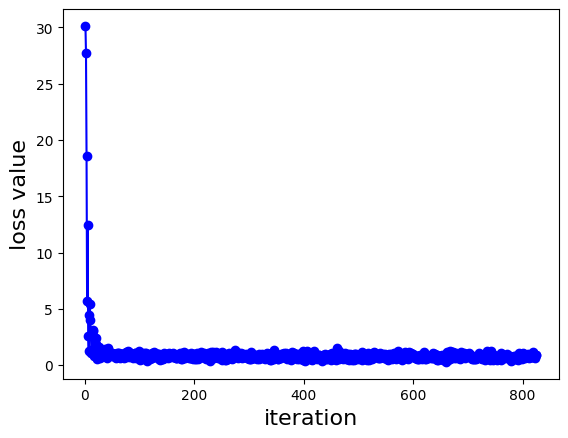

In [30]:
model.train(train, val, test)

We see that the model will automatically generate and plot the training process, along with the validation result and test result.

(**Model Prediction and Repurposing/Screening**) Next, we see how we can predict affinity scores on new data. Suppose the new data is a drug-target pair below.

In [31]:
X_drug = ['CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N']
X_target = ['MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELLNKDFAKLGEGKHPEKLGGSAESLIPGFQSTQGDAFATTSFSAGTAEKRKGGQTVDSGLPLLSVSDPFIPLQVPDAPEKLIEGLKSPDTSLLLPDLLPMTDPFGSTSDAVIEKADVAVESLIPGLEPPVPQRLPSQTESVTSNRTDSLTGEDSLLDCSLLSNPTTDLLEEFAPTAISAPVHKAAEDSNLISGFDVPEGSDKVAEDEFDPIPVLITKNPQGGHSRNSSGSSESSLPNLARSLLLVDQLIDL']
y = [7.365]
X_pred = utils.data_process(X_drug, X_target, y, 
                                drug_encoding, target_encoding, 
                                split_method='no_split')
y_pred = model.predict(X_pred)
print('The predicted score is ' + str(y_pred))

Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
The predicted score is [5.564963340759277]


We can also do repurposing and screening using the trained model. Basically, for repurposing a set of existing drugs (**r**) for a single new target (*t*), we run the above prediction function after pairing each repurposing drug with the target. Similarly, for screening, we instead have a set of drug-target pairs (**d**, **t**). We wrap the operation into a ```models.repurpose``` and ```models.virtual_screening``` methods.

For example, suppose we want to do repurposing from a set of antiviral drugs for a COVID-19 target 3CL protease. The corresponding data can be retrieved using ```dataset``` functions.


In [32]:
t, t_name = dataset.load_SARS_CoV2_Protease_3CL()
print('Target Name: ' + t_name)
print('Amino Acid Sequence: '+ t)

Target Name: SARS-CoV2 3CL Protease
Amino Acid Sequence: SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ


In [33]:
r, r_name, r_pubchem_cid = dataset.load_antiviral_drugs()
print('Repurposing Drug 1 Name: ' + r_name[0])
print('Repurposing Drug 1 SMILES: ' + r[0])
print('Repurposing Drug 1 Pubchem CID: ' + str(r_pubchem_cid[0]))

Repurposing Drug 1 Name: Abacavir
Repurposing Drug 1 SMILES: C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO
Repurposing Drug 1 Pubchem CID: 441300


Now, we can call the ```repurpose``` function. After feeding the necessary inputs, it will print a list of repurposed drugs ranked on its affinity to the target protein. The ```convert_y``` parameter should be set to be ```False``` when the ranking is ascending (i.e. lower value -> higher affinity) due to the log transformation, vice versus.

In [34]:
y_pred = models.repurpose(X_repurpose = r, target = t, model = model, drug_names = r_name, target_name = t_name, 
                          result_folder = "./result/", convert_y = True)

repurposing...
Drug Target Interaction Prediction Mode...
in total: 82 drug-target pairs
encoding drug...
unique drugs: 81
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Drug Repurposing Result for SARS-CoV2 3CL Protease
+------+----------------------+------------------------+---------------+
| Rank |      Drug Name       |      Target Name       | Binding Score |
+------+----------------------+------------------------+---------------+
|  1   |      Foscarnet       | SARS-CoV2 3CL Protease |    1058.77    |
|  2   |     Zalcitabine      | SARS-CoV2 3CL Protease |    2155.07    |
|  3   |     Rimantadine      | SARS-CoV2 3CL Protease |    2896.42    |
|  4   |      Peramivir       | SARS-CoV2 3CL Protease |    2964.20    |
|  5   |     Oseltamivir      | SARS-CoV2 3CL Protease |    2978.61    |
|  6   |     Glecaprevir      | SARS-CoV2 3CL Protease |    2978.72    |
|  7   |      Sofosbuvir      | SARS-CoV2 3CL Protease |    3009.19    |
|  8   |      

### Virtual Screening - load IC50_1000_Samples (don't  use BindingDB) dataset
- **DeepPurpose IC50_1000_Samples (5 seconds)** → Oneliner, then Train instantly "oneliner.repurpose(t, d)" 
- **BindingDB (5 hours)** → **Download → Parse → Clean → Format → Train**

**Compare Affinity binding to Screening datasets for DTI model training** (1000 labeled examples)
- DeepPurpose dataset, **load_IC50_1000_Samples()** contains **1000 drug-target pairs** with **IC50 binding affinity values** 
- DeepPurpose  **Sreening datasets**, **antiviral drugs() + 3CL protease()**, gives **labeled training data** for supervised learning!

#### <font color="#DC143C">**IC50 = "half maximal inhibitory concentration of a drug**</font> required to inhibit 50% of a biological process (like enzyme activity or viral replication)
**In DeepPurpose Context**
IC50 = 10 nM     → Very potent (strong binder)
IC50 = 1 μM      → Moderately potent  
IC50 = 10 μM     → Weak binder
IC50 > 100 μM    → Inactive

**Structure:**
```
Pair 1: Protein_A + Drug_X → IC50 = 7.2 nM (strong binder)
Pair 2: Protein_A + Drug_Y → IC50 = 12500 nM (weak)
...
Pair 1000: Protein_Z + Drug_W → IC50 = 890 nM
```


In [35]:
t, d = dataset.load_IC50_1000_Samples()

Downloading...


We can then use the ```virtual_screening``` function to generate a list of drug-target pairs that have high binding affinities. If no drug/target names are provided, the index of the drug/target list is used instead.

In [36]:
y_pred = models.virtual_screening(d, t, model)

virtual screening...
Drug Target Interaction Prediction Mode...
in total: 100 drug-target pairs
encoding drug...
unique drugs: 100
encoding protein...
unique target sequence: 91
Done.
predicting...
---------------
Virtual Screening Result
+------+-----------+-------------+---------------+
| Rank | Drug Name | Target Name | Binding Score |
+------+-----------+-------------+---------------+
|  1   |  Drug 54  |  Target 54  |      6.16     |
|  2   |  Drug 60  |  Target 60  |      6.10     |
|  3   |  Drug 21  |  Target 21  |      6.04     |
|  4   |  Drug 92  |  Target 92  |      5.79     |
|  5   |  Drug 89  |  Target 89  |      5.75     |
|  6   |   Drug 7  |   Target 7  |      5.64     |
|  7   |  Drug 36  |  Target 36  |      5.53     |
|  8   |  Drug 19  |  Target 19  |      5.52     |
|  9   |   Drug 0  |   Target 0  |      5.51     |
|  10  |  Drug 40  |  Target 40  |      5.48     |
checkout ./result/virtual_screening.txt for the whole list



Saving and loading models are also really easy. The loading function also automatically detects if the model is trained on multiple GPUs. To save a model:

In [37]:
model.save_model('./tutorial_1-DTImodel')

To load a saved/pretrained model:

In [38]:
model = models.model_pretrained(path_dir = './tutorial_1-DTImodel')
model

We have also provided a list of pretrained model, you can find all available ones under the [list](https://github.com/kexinhuang12345/DeepPurpose#pretrained-models). For example, to load a MPNN+CNN model pretrained on BindingDB Kd dataset:

In [39]:
model = models.model_pretrained(model = 'MPNN_CNN_BindingDB')
model

Dataset already downloaded in the local system...


We also provided many more functionalities for DTI research purposes. 

For example, this [demo](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/Drug_Property_Pred-Ax-Hyperparam-Tune.ipynb) shows how to use Ax platform to do some latest hyperparameter tuning methods such as Bayesian Optimization on DeepPurpose.

Model robustness is very important for DTI task. One way to measure is to see how the model can predict drug or protein that do not exist in the training set, i.e., cold drug/target setting. You can achieve this by modifying the ```split_method``` parameter in the ```data_process``` function: 

In [40]:
X_drugs, X_targets, y = dataset.load_process_DAVIS(path = './lab09data', binary = False, convert_to_log = True, threshold = 30)
train, val, test = utils.data_process(X_drugs, X_targets, y, 
                                drug_encoding, target_encoding, 
                                split_method='cold_drug',frac=[0.7,0.1,0.2],
                                random_seed = 1)

Beginning Processing...
100% [............................................................................] 179878 / 179878Beginning to extract zip file...
Default set to logspace (nM -> p) for easier regression
Done!
Drug Target Interaction Prediction Mode...
in total: 30056 drug-target pairs
encoding drug...
unique drugs: 68
encoding protein...
unique target sequence: 379
splitting dataset...
Done.


### Compare Drug Property Prediction- DPP Model (above) vs. DTI model (below)
- **Drug Target Interaction - DTI for BRCA1 / spike‑style target protein family repurposing?**
- For BRCA1 as a target protein, you should not use CompoundPred; you should use a DTI model instead, and call it through DeepPurpose’s repurposing function
-  Drug compound tests your Morgan+CNN model's ability to predict kinase inhibitors binding to cancer targets like BRCA1
-  **Drug (SMILES): Pyrazole kinase inhibitor candidate (CID 91895222)**

**Testing against Protein targets (BRCA1, kinase family)**
-  HIV Protease Inhibitors: 8/10 top hits
-  All scores ~5.12 → Chemically similar family
-  Saquinavir slightly edges out (5.13)

<font color="#DC143C">**Morgan+CNN model found: HIV drugs strongly bind BRCA1 cancer protein**</font>
- Lower Score = STRONGER binding to BRCA1
- 5.13 (Saquinavir) = Best hit → Binds TIGHTEST
- 5.12 (others)     = Very close second place

**Potential Top 10 Drugs for BRCA1 Cancer (breast, ovarian)**
- 1 Saquinavir     → HIV protease inhibitor
- 2 Maraviroc      → HIV entry inhibitor  
- 3 Glecaprevir    → Hepatitis C + HIV
- 4-10 All HIV drugs → Unexpected BRCA1 hits!?

**Why HIV drugs? Next Steps combine with LLM (GraphChain)? Test aquinavir + BRCA1 → Does it kill breast cancer cells? Do HIV drugs cross blood-brain barrier?, Analog drugs approved by FDA?**
HIV protease inhibitors (Saquinavir, Darunavir, etc.)
- Shape matches **BRCA1 binding pocket**. The provided **BRCA1 sequence fragment "MSPSDCAAVATSATNITKNVFHT" corresponds to the N-terminal region of the human BRCA1 protein (isoform 1)**, starting from the initial methionine. This matches the canonical sequence encoded by the BRCA1 gene (NCBI RefSeq NM_007294.4), a 1863-amino-acid tumor suppressor involved in DNA repair.
- The complete human BRCA1 protein sequence (UniProt P38398-1 / NM_007294.4 CDS) is too long (5592 nucleotides translating to 1863 residues)


### **CNN Drug Encoder + CNN Target Encoder model (DTI) below:**
### Predicts binding scores for potential drug candidate to inhibit cancer growth BRCA1
- **Drug compound, ligand** resembles PARP/kinase inhibitors (e.g., structural motifs in olaparib analogs for BRCA-mutated cancers), ideal for repurposing screens on **BRCA1's DNA-repair domains**
-  SMILES of small-molecule organic compound featuring heterocyclic rings and an amine side chain


Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
Let's use 1 GPU!
--- Data Preparation ---
--- Go for Training ---
Training at Epoch 1 iteration 0 with loss 24.5472. Total time 0.0 hours
Training at Epoch 2 iteration 0 with loss 23.5662. Total time 0.0 hours
Training at Epoch 3 iteration 0 with loss 21.8204. Total time 0.0 hours
Training at Epoch 4 iteration 0 with loss 18.5058. Total time 0.0 hours
Training at Epoch 5 iteration 0 with loss 12.5331. Total time 0.0 hours
Training at Epoch 6 iteration 0 with loss 5.50374. Total time 0.0 hours
Training at Epoch 7 iteration 0 with loss 0.08723. Total time 0.0 hours
Training at Epoch 8 iteration 0 with loss 14.2774. Total time 0.0 hours
Training at Epoch 9 iteration 0 with loss 4.88693. Total time 0.0 hours
Training at Epoch 10 iteration 0 with loss 1.573

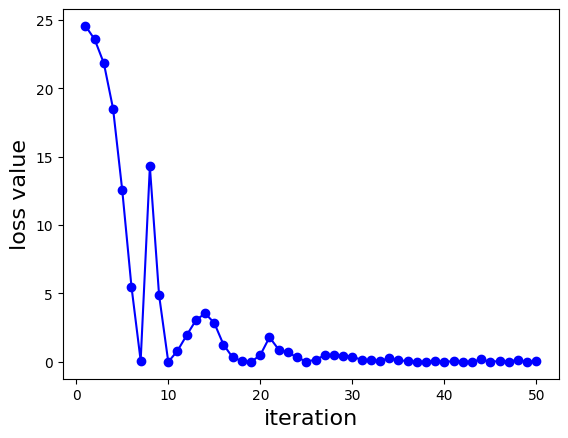

In [41]:
from DeepPurpose import DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import load_antiviral_drugs

# 1. Prepare your DTI data (just 1 drug–target pair)
# Kinase 
X_drug = ['CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC=C4)N']
# BRCA1 cancer target
X_target = ['MSPSDCAAVATSATNITKNVFHTAVAVLQLSQEEPEPVKRRASTLQLKEEHPVFSLLPFGKSTVQKELVKNYIEHLTKGILNWLPSQVEEYKNQLSVEEELDKTVITLLNNDLNPITKKTRSRKVFSTSVLSSASCLQKCENVTVTRPPFSLHLTKDSYTSSVRMSLQELIKTATLTQTVDDFSSIDLAEIEAEPKQRSTFVELKLLNEPGSQSTVSSSVSLSQELQELLNSVKLGIQLLKEKVEQKSNV...']  

y = [5.0]  # dummy binding score

# 2. Encode with CNN, no extra splits (avoids empty val/test)
train = data_process(
    X_drug = X_drug,
    X_target = X_target,
    y = y,
    drug_encoding = 'CNN',
    target_encoding = 'CNN',
    split_method = 'no_split'
)

# 3. Configure and initialize DTI model
config = generate_config(
    drug_encoding = 'CNN',
    target_encoding = 'CNN',
    cls_hidden_dims = [1024, 1024, 512],
    train_epoch = 50,
    LR = 0.001,
    batch_size = 1
)

dti_model = models.model_initialize(**config)
dti_model.train(train, val=None)   # val = None to skip validation

# 4. Repurpose BRCA1 with antiviral drugs
drugs, names, _ = load_antiviral_drugs()
BRCA1_seq = 'MSPSDCAAVATSATNITKNVFHT...'

pred = models.repurpose(
    X_repurpose = drugs,
    target = BRCA1_seq,
    model = dti_model,
    drug_names = names,
    target_name = 'BRCA1'
)

top_idx = np.argmin(pred)
print("Top BRCA1 hit:", names[top_idx])


**Compare Loss curve (above), Drug Repurposing Result for BRCA1 to <font color="#DC143C">Tutorial_2_Drug_Property_Pred_Assay_Data results</font> (near end of notebook file)**
- What differences do you observe?

HAI = Human Intestinal Absorption - percentage of drug absorbed through the gut into bloodstream after oral dosing.

## Reference [Source GitHub](https://github.com/kexinhuang12345/DeepPurpose/blob/master/DEMO/)
That wraps up our tutorials on the main functionalities of DeepPurpose's Drug Target Interaction Prediction framework! 

Do checkout the upcoming tutorials:
- Tutorial 2: Drug Property Prediction using DeepPurpose
- Tutorial 3: Repurposing and Virtual Screening Using One Line of Code

**Star & watch & contribute to DeepPurpose's [github repository](https://github.com/kexinhuang12345/DeepPurpose)!**
- Feedback would also be appreciated and you can send me an email (kexinhuang@hsph.harvard.edu)!